# Class 3: Data Cleaning and Transformation


---
## Setup — install and import libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.impute import KNNImputer

pd.set_option('display.float_format', '{:.2f}'.format)

---
## 1. The dataset

We will use a fictional dataset of **university students** throughout all activities.
It contains numeric, categorical, ordinal, and missing values — and some duplicates.

| Column | Type | Description |
|--------|------|-------------|
| `student_id` | int | Unique identifier |
| `name` | str | Student name |
| `age` | int | Age in years |
| `hours_studied` | float | Weekly study hours |
| `income` | float | Monthly family income (USD) |
| `score` | float | Exam score (0–100), has missing values |
| `city` | str | City of origin (nominal) |
| `education` | str | Parent education level (ordinal) |

In [5]:
df = pd.read_excel('University Students.xlsx')
df = df.drop(columns='Unnamed: 0')
df 

,student_id,name,age,hours_studied,income,score,city,education
0,1,Ana,20,5.00,1000,70.00,Paris,Bachelor
1,2,Bruno,22,3.00,1500,60.00,London,High school
2,3,Carla,21,4.00,2000,NaN,Tokyo,Master
3,4,Diego,25,2.00,2500,50.00,Paris,High school
4,5,Elena,19,6.00,3000,80.00,London,PhD
5,6,Fran,23,3.50,1200,65.00,Tokyo,Bachelor
6,7,Gabi,24,4.50,1800,NaN,Paris,Master
7,8,Hugo,20,5.50,2200,75.00,London,PhD
8,9,Iris,22,2.50,1600,55.00,Tokyo,High school
9,10,Juan,21,4.00,120000,72.00,Paris,Bachelor


---
## 2. Deduplication — exact vs. logical duplicates

**Exact duplicates:** rows that are completely identical across all columns.

**Logical duplicates:** rows representing the same real entity but differing in formatting or values (e.g. different casing, different ID).

In [6]:
# --- Exact duplicates ---
print("Exact duplicates:")
print(df[df.duplicated()])

df_clean = df.drop_duplicates()
print("\nRows after removing exact duplicates:", len(df_clean))

Exact duplicates:
    student_id   name  age  hours_studied  income  score    city    education
10           2  Bruno   22           3.00    1500  60.00  London  High school

Rows after removing exact duplicates: 11


In [ ]:
# --- Logical duplicates ---
# Same student_id should not appear twice
print("Duplicated student_ids:")
print(df_clean[df_clean.duplicated(subset='student_id', keep=False)])

# Normalize name to detect case differences
df_clean = df_clean.copy()
df_clean['name_normalized'] = df_clean['name'].str.strip().str.lower()


print("\nLogical name duplicates (after normalizing case):")
print(df_clean[df_clean.duplicated(subset=['student_id'], keep=False)][['student_id','name','name_normalized']])

Duplicated student_ids:
    student_id   name  age  hours_studied  income  score   city education
2            3  Carla   21           4.00    2000    NaN  Tokyo    Master
11           3  CARLA   21           4.00    2000    NaN  Tokyo    Master

Logical name duplicates (after normalizing case):
    student_id   name name_normalized
2            3  Carla           carla
11           3  CARLA           carla


In [8]:
# Keep first occurrence of each student_id
df_clean = df_clean.drop_duplicates(subset='student_id', keep='first').drop(columns='name_normalized')
df_clean = df_clean.reset_index(drop=True)
print("Final shape after deduplication:", df_clean.shape)
df_clean

Final shape after deduplication: (10, 8)


,student_id,name,age,hours_studied,income,score,city,education
0,1,Ana,20,5.00,1000,70.00,Paris,Bachelor
1,2,Bruno,22,3.00,1500,60.00,London,High school
2,3,Carla,21,4.00,2000,NaN,Tokyo,Master
3,4,Diego,25,2.00,2500,50.00,Paris,High school
4,5,Elena,19,6.00,3000,80.00,London,PhD
5,6,Fran,23,3.50,1200,65.00,Tokyo,Bachelor
6,7,Gabi,24,4.50,1800,NaN,Paris,Master
7,8,Hugo,20,5.50,2200,75.00,London,PhD
8,9,Iris,22,2.50,1600,55.00,Tokyo,High school
9,10,Juan,21,4.00,120000,72.00,Paris,Bachelor


### Activity
1. How many exact duplicates were in the original dataset?
2. How many logical duplicates were found by `student_id`?
3. Why is it important to normalize text (lowercase) before checking for logical duplicates?

---
## 3. KNN Imputation

Fills missing values using the **K nearest neighbors** — rows that are most similar on the known features.
The missing value is replaced by the average of those neighbors' values.

**Features used:** `age` and `hours_studied`  
**Target:** `score` (has missing values)

In [9]:
# Check missing values
print("Missing values per column:")
print(df_clean.isnull().sum())
print("\nRows with missing score:")
print(df_clean[df_clean['score'].isnull()][['student_id','name','age','hours_studied','score']])

Missing values per column:
student_id       0
name             0
age              0
hours_studied    0
income           0
score            2
city             0
education        0
dtype: int64

Rows with missing score:
   student_id   name  age  hours_studied  score
2           3  Carla   21           4.00    NaN
6           7   Gabi   24           4.50    NaN


In [10]:
# Apply KNN imputation with K=2
imputer = KNNImputer(n_neighbors=2)

features_for_imputation = ['age', 'hours_studied', 'score']
df_imputed = df_clean.copy()
df_imputed[features_for_imputation] = imputer.fit_transform(df_clean[features_for_imputation])

print("Scores after KNN imputation:")
df_imputed[['student_id','name','age','hours_studied','score']]

Scores after KNN imputation:


,student_id,name,age,hours_studied,score
0,1,Ana,20.00,5.00,70.00
1,2,Bruno,22.00,3.00,60.00
2,3,Carla,21.00,4.00,71.00
3,4,Diego,25.00,2.00,50.00
4,5,Elena,19.00,6.00,80.00
5,6,Fran,23.00,3.50,65.00
6,7,Gabi,24.00,4.50,62.50
7,8,Hugo,20.00,5.50,75.00
8,9,Iris,22.00,2.50,55.00
9,10,Juan,21.00,4.00,72.00


### Activity
1. Which two students are the nearest neighbors of Carla? Why?
2. What would the imputed value be if K=3?
3. Why do we use `age` and `hours_studied` for the distance and not `score`?

---
## 4. Winsorization

Caps extreme values at a given percentile threshold.  
The row is kept — only the extreme value is replaced.

We will apply it to the `income` column, which contains one large outlier.

Income distribution:
count       10.00
mean     13680.00
std      37361.83
min       1000.00
25%       1525.00
50%       1900.00
75%       2425.00
max     120000.00
Name: income, dtype: float64


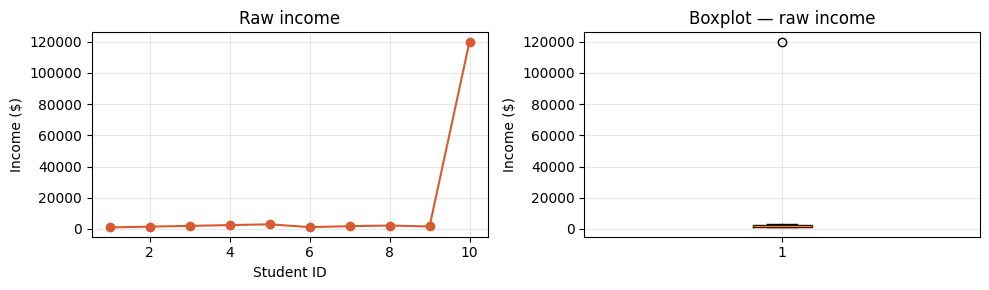

In [11]:
print("Income distribution:")
print(df_imputed['income'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(df_imputed['student_id'], df_imputed['income'], marker='o', color='#D85A30')
axes[0].set_title('Raw income')
axes[0].set_xlabel('Student ID')
axes[0].set_ylabel('Income ($)')
axes[0].grid(alpha=0.3)

axes[1].boxplot(df_imputed['income'], vert=True)
axes[1].set_title('Boxplot — raw income')
axes[1].set_ylabel('Income ($)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Winsorize at 10th–90th percentile
lower = df_imputed['income'].quantile(0.10)
upper = df_imputed['income'].quantile(0.90)
print(f"Lower threshold (10th pct): ${lower:,.0f}")
print(f"Upper threshold (90th pct): ${upper:,.0f}")

df_winsor = df_imputed.copy()
df_winsor['income_winsorized'] = df_winsor['income'].clip(lower=lower, upper=upper)

comparison = df_winsor[['student_id','name','income','income_winsorized']]
comparison

Lower threshold (10th pct): $1,180
Upper threshold (90th pct): $14,700


C:\Users\USER\AppData\Local\Temp\ipykernel_16948\1578576544.py:8: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_winsor['income_winsorized'] = df_winsor['income'].clip(lower=lower, upper=upper)


,student_id,name,income,income_winsorized
0,1,Ana,1000,1180
1,2,Bruno,1500,1500
2,3,Carla,2000,2000
3,4,Diego,2500,2500
4,5,Elena,3000,3000
5,6,Fran,1200,1200
6,7,Gabi,1800,1800
7,8,Hugo,2200,2200
8,9,Iris,1600,1600
9,10,Juan,120000,14700


### Activity
1. Which student's income was capped? By how much?
2. What happens to the mean before and after winsorization? Calculate both.
3. Why is winsorization preferred over simply deleting the outlier row?

---
## 5. Log transformation

Compresses large values by applying log, reducing the influence of extreme values.  
All values must be > 0. We apply **log10** to `income`.

In [13]:
df_log = df_winsor.copy()
df_log['income_log10'] = np.log10(df_log['income'])

print("Raw vs log10 income:")
df_log[['student_id','name','income','income_log10']].round(2)

Raw vs log10 income:


,student_id,name,income,income_log10
0,1,Ana,1000,3.00
1,2,Bruno,1500,3.18
2,3,Carla,2000,3.30
3,4,Diego,2500,3.40
4,5,Elena,3000,3.48
5,6,Fran,1200,3.08
6,7,Gabi,1800,3.26
7,8,Hugo,2200,3.34
8,9,Iris,1600,3.20
9,10,Juan,120000,5.08


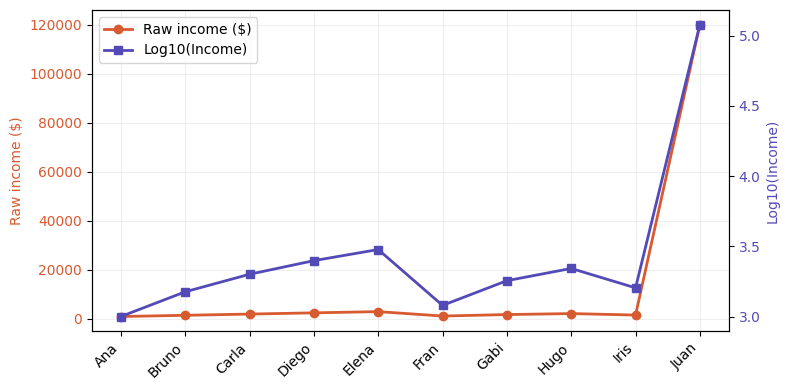

In [14]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

x = range(len(df_log))
ax1.plot(x, df_log['income'], color='#D85A30', marker='o', linewidth=2, label='Raw income ($)')
ax2.plot(x, df_log['income_log10'], color='#534AB7', marker='s', linewidth=2, label='Log10(Income)')

ax1.set_ylabel('Raw income ($)', color='#D85A30')
ax2.set_ylabel('Log10(Income)', color='#534AB7')
ax1.set_xticks(x)
ax1.set_xticklabels(df_log['name'], rotation=45, ha='right')
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax2.tick_params(axis='y', labelcolor='#534AB7')
ax1.grid(alpha=0.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Activity
1. What is the log10 of Juan's income ($120,000)? Calculate it manually.
2. Compare the mean of raw income vs log10 income. Which is more representative?
3. What would you use if some incomes were 0? (hint: log1p)

---
## 6. Normalization (Min-Max scaling)

Rescales values to the range **[0, 1]**.

$$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

We apply it to `age`, `hours_studied`, and `score`.

In [15]:
df_norm = df_log.copy()
cols_to_normalize = ['age', 'hours_studied', 'score']

scaler = MinMaxScaler()
df_norm[['age_norm', 'hours_norm', 'score_norm']] = scaler.fit_transform(df_norm[cols_to_normalize])

print("Before and after normalization:")
df_norm[['name','age','age_norm','hours_studied','hours_norm','score','score_norm']].round(2)

Before and after normalization:


,name,age,age_norm,hours_studied,hours_norm,score,score_norm
0,Ana,20.00,0.17,5.00,0.75,70.00,0.67
1,Bruno,22.00,0.50,3.00,0.25,60.00,0.33
2,Carla,21.00,0.33,4.00,0.50,71.00,0.70
3,Diego,25.00,1.00,2.00,0.00,50.00,0.00
4,Elena,19.00,0.00,6.00,1.00,80.00,1.00
5,Fran,23.00,0.67,3.50,0.38,65.00,0.50
6,Gabi,24.00,0.83,4.50,0.62,62.50,0.42
7,Hugo,20.00,0.17,5.50,0.88,75.00,0.83
8,Iris,22.00,0.50,2.50,0.12,55.00,0.17
9,Juan,21.00,0.33,4.00,0.50,72.00,0.73


### Activity
1. Which student has the highest normalized score? Which has the lowest?
2. What would happen to all normalized values if a new student with age=50 joined the dataset?
3. Why must normalization be fit on training data only?

---
## 7. Standardization (Z-score)

Rescales values so the variable has **mean = 0** and **standard deviation = 1**.

$$Z = \frac{X - \mu}{\sigma}$$

We apply it to `income_winsorized` to compare with normalization.

In [16]:
df_std = df_norm.copy()
std_scaler = StandardScaler()

cols_to_standardize = ['age', 'hours_studied', 'score']
df_std[['age_z', 'hours_z', 'score_z']] = std_scaler.fit_transform(df_std[cols_to_standardize])

print("Z-scores:")
df_std[['name','age','age_z','hours_studied','hours_z','score','score_z']].round(2)

Z-scores:


,name,age,age_z,hours_studied,hours_z,score,score_z
0,Ana,20.00,-0.95,5.00,0.82,70.00,0.45
1,Bruno,22.00,0.17,3.00,-0.82,60.00,-0.68
2,Carla,21.00,-0.39,4.00,0.00,71.00,0.56
3,Diego,25.00,1.84,2.00,-1.63,50.00,-1.82
4,Elena,19.00,-1.51,6.00,1.63,80.00,1.58
5,Fran,23.00,0.73,3.50,-0.41,65.00,-0.12
6,Gabi,24.00,1.28,4.50,0.41,62.50,-0.40
7,Hugo,20.00,-0.95,5.50,1.22,75.00,1.01
8,Iris,22.00,0.17,2.50,-1.22,55.00,-1.25
9,Juan,21.00,-0.39,4.00,0.00,72.00,0.67


In [17]:
print(f"Mean of age_z:  {df_std['age_z'].mean():.10f}  (should be ~0)")
print(f"Std  of age_z:  {df_std['age_z'].std():.4f}   (should be ~1)")
print(f"\nMean of score_z: {df_std['score_z'].mean():.10f}")
print(f"Std  of score_z: {df_std['score_z'].std():.4f}")

Mean of age_z:  0.0000000000  (should be ~0)
Std  of age_z:  1.0541   (should be ~1)

Mean of score_z: 0.0000000000
Std  of score_z: 1.0541


### Activity
1. Which student has the most extreme Z-score for `score`? What does that mean?
2. A Z-score greater than 3 or less than -3 is often considered an outlier. Are there any?
3. When would you choose standardization over normalization?

---
## 8. Label Encoding

Converts categorical text values to integers automatically.  
Order is assigned arbitrarily by the encoder — **safe only for tree-based models or ordinal data**.

We apply it to `city` (nominal — to illustrate the risk) and compare with ordinal encoding.

In [18]:
df_enc = df_std.copy()

# Creamos el codificador
le = LabelEncoder()

# Convertimos la columna 'city' a números y la guardamos en 'city_label'
df_enc['city_label'] = le.fit_transform(df_enc['city'])

# Mostramos cómo quedó la conversión
print("Conversión de ciudades a números:")
print("----------------------------------")

# Recorremos cada ciudad y su número asignado
ciudades = le.classes_          # Lista de ciudades únicas
numeros  = range(len(ciudades)) # Números del 0 en adelante

for ciudad, numero in zip(ciudades, numeros):
    print(f"  {ciudad} → {numero}")

# Mostramos las columnas relevantes del resultado
print("\nResultado:")
print(df_enc[['name', 'city', 'city_label']])

Conversión de ciudades a números:
----------------------------------
  London → 0
  Paris → 1
  Tokyo → 2

Resultado:
    name    city  city_label
0    Ana   Paris           1
1  Bruno  London           0
2  Carla   Tokyo           2
3  Diego   Paris           1
4  Elena  London           0
5   Fran   Tokyo           2
6   Gabi   Paris           1
7   Hugo  London           0
8   Iris   Tokyo           2
9   Juan   Paris           1


### Activity
1. What order did the encoder assign to the cities? Is it meaningful?
2. If a KNN model uses `city_label`, will Tokyo (2) be treated as farther from London (1) than London is from Paris (0)? Is that correct?
3. What encoding should be used for `city` instead, and why?

---
## 9. One-Hot Encoding

Creates one binary column per category. No numeric order is implied.  
Drop one column (k-1) to avoid the **dummy variable trap**.

We apply it to `city` (nominal variable).

In [19]:
df_ohe = df_enc.copy()

# get_dummies applies OHE and drops one column automatically with drop_first=True
city_dummies = pd.get_dummies(df_ohe['city'], prefix='city', drop_first=True)

df_ohe = pd.concat([df_ohe, city_dummies], axis=1)

print("One-hot encoded city columns:")
df_ohe[['name','city'] + list(city_dummies.columns)]

One-hot encoded city columns:


,name,city,city_Paris,city_Tokyo
0,Ana,Paris,True,False
1,Bruno,London,False,False
2,Carla,Tokyo,False,True
3,Diego,Paris,True,False
4,Elena,London,False,False
5,Fran,Tokyo,False,True
6,Gabi,Paris,True,False
7,Hugo,London,False,False
8,Iris,Tokyo,False,True
9,Juan,Paris,True,False


In [20]:
# Show what happens WITHOUT drop_first (dummy variable trap)
city_all = pd.get_dummies(df_ohe['city'], prefix='city', drop_first=False)
print("All columns (dummy variable trap — redundant column):")
print(city_all.head(5))
print("\nNote: city_Paris = 1 - city_London - city_Tokyo (perfectly predictable)")

All columns (dummy variable trap — redundant column):
   city_London  city_Paris  city_Tokyo
0        False        True       False
1         True       False       False
2        False       False        True
3        False        True       False
4         True       False       False

Note: city_Paris = 1 - city_London - city_Tokyo (perfectly predictable)


### Activity
1. How many columns does OHE create for `city`? How many do we keep after drop_first?
2. If a student has city_London=0 and city_Tokyo=0, which city are they from?
3. The `city` column has 3 unique values. What if it had 100 unique cities — what problem would arise?

---
## 10. Ordinal Encoding

Like label encoding, but the **analyst explicitly defines the order**.  
The mapping reflects real domain knowledge, not alphabetical order.

We apply it to `education` (ordinal variable: High school < Bachelor < Master < PhD).

In [21]:
df_final = df_ohe.copy()

# Define the explicit order
education_order = [['High school', 'Bachelor', 'Master', 'PhD']]

oe = OrdinalEncoder(categories=education_order)
df_final['education_encoded'] = oe.fit_transform(df_final[['education']]).astype(int)

print("Ordinal encoding mapping for education:")
for lvl, idx in zip(education_order[0], range(len(education_order[0]))):
    print(f"  {lvl} → {idx}")

print("\nResult:")
df_final[['name','education','education_encoded']]

Ordinal encoding mapping for education:
  High school → 0
  Bachelor → 1
  Master → 2
  PhD → 3

Result:


,name,education,education_encoded
0,Ana,Bachelor,1
1,Bruno,High school,0
2,Carla,Master,2
3,Diego,High school,0
4,Elena,PhD,3
5,Fran,Bachelor,1
6,Gabi,Master,2
7,Hugo,PhD,3
8,Iris,High school,0
9,Juan,Bachelor,1


### Activity
1. What order would label encoding assign to education levels? Is it correct?
2. Why is the difference between ordinal and label encoding critical for a linear regression model?
3. Could you apply one-hot encoding to `education` instead? What are the trade-offs?